## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from utils import column_encoder, create_tf_dataset, recommend
from models import RecommenderModel

I0000 00:00:1785491015.193066   23961 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785491017.369571   23961 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785491024.535997   23961 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 2. Load Dataset

In [2]:
data = pd.read_csv('personalized_recommendation_dataset.csv')

data

,User_ID,Item_ID,Category,Rating,Timestamp,Price,Platform,Location
0,User_913,Item_52,Movies,2.0,2023-05-15,369.55,Web,Africa
1,User_3457,Item_66,Electronics,1.4,2023-08-19,255.15,Web,Africa
2,User_1629,Item_1467,Sports,2.7,2024-03-27,296.69,Web,Europe
3,User_3463,Item_697,Movies,1.6,2023-12-03,55.59,Tablet,North America
4,User_2941,Item_1736,Games,3.4,2023-02-06,366.22,Web,South America
...,...,...,...,...,...,...,...,...
149995,User_577,Item_1195,Sports,2.4,2023-10-24,182.04,Web,Europe
149996,User_4996,Item_1335,Books,3.4,2023-07-21,345.84,Mobile App,Europe
149997,User_2804,Item_1956,Games,1.6,2024-02-27,203.77,Mobile App,Europe
149998,User_1443,Item_397,Books,1.4,2024-01-23,475.06,Smart TV,Europe


## 3. Explore Dataset

In [3]:
print(data.info())
print(data.describe())
print(data.isnull().sum())
print(data.nunique())
print(f'Number Of Duplicates: {data.duplicated().sum()}')

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   User_ID    150000 non-null  str    
 1   Item_ID    150000 non-null  str    
 2   Category   150000 non-null  str    
 3   Rating     150000 non-null  float64
 4   Timestamp  150000 non-null  str    
 5   Price      150000 non-null  float64
 6   Platform   150000 non-null  str    
 7   Location   150000 non-null  str    
dtypes: float64(2), str(6)
memory usage: 9.2 MB
None
              Rating          Price
count  150000.000000  150000.000000
mean        2.994918     252.312944
std         1.153429     142.754120
min         1.000000       5.000000
25%         2.000000     128.817500
50%         3.000000     252.610000
75%         4.000000     375.630000
max         5.000000     500.000000
User_ID      0
Item_ID      0
Category     0
Rating       0
Timestamp    0
Price        0
Platform     0
Location 

## 4. Preprocessing

Encode categorical columns and convert the timestamp into days since interaction.

In [4]:
columns = ['User_ID', 'Item_ID', 'Category', 'Platform', 'Location']

data, _ = column_encoder(data, *columns)

data['Timestamp'] = pd.to_datetime(data['Timestamp'])
data = data.sort_values('Timestamp')

time_delta = pd.Timestamp.now() - data['Timestamp']
time_delta = np.round(time_delta / pd.Timedelta(days=1), 0)

data['Days_since_interaction'] = time_delta

data

,User_ID,Item_ID,Category,Rating,Timestamp,Price,Platform,Location,Days_since_interaction
10773,3418,706,6,4.6,2022-12-24,175.34,3,0,1316.0
97910,2707,1051,8,4.8,2022-12-24,487.57,2,5,1316.0
13563,2962,634,3,1.6,2022-12-24,138.19,0,2,1316.0
34060,4674,363,1,4.1,2022-12-24,290.17,2,3,1316.0
34589,4647,886,5,3.3,2022-12-24,197.78,0,4,1316.0
...,...,...,...,...,...,...,...,...,...
64407,475,448,6,4.0,2024-12-23,155.66,3,3,586.0
68344,3243,1855,6,2.5,2024-12-23,141.37,2,3,586.0
144945,647,283,8,3.9,2024-12-23,435.80,3,2,586.0
29426,2974,30,7,1.8,2024-12-23,129.07,1,3,586.0


## 5. Train/Test Split

In [5]:
split_index = int(len(data) * 0.8)

train_data = data.iloc[:split_index].copy()
test_data = data.iloc[split_index:].copy()

print(f'Train shape: {train_data.shape}')
print(f'Test shape: {test_data.shape}')

print(
    f"\nTrain Data Time Length:\n"
    f"{train_data['Timestamp'].min()} --> {train_data['Timestamp'].max()}"
)

print(
    f"\nTest Data Time Length:\n"
    f"{test_data['Timestamp'].min()} --> {test_data['Timestamp'].max()}"
)

Train shape: (120000, 9)
Test shape: (30000, 9)

Train Data Time Length:
2022-12-24 00:00:00 --> 2024-07-30 00:00:00

Test Data Time Length:
2024-07-30 00:00:00 --> 2024-12-23 00:00:00


## 6. Feature Scaling

In [6]:
price_scaler = StandardScaler()

train_data['Price'] = price_scaler.fit_transform(
    train_data['Price'].to_numpy().reshape(-1, 1)
)

test_data['Price'] = price_scaler.transform(
    test_data['Price'].to_numpy().reshape(-1, 1)
)

## Creating NumUsers and NumItems

In [7]:
num_users = train_data['User_ID'].nunique()
num_items = train_data['Item_ID'].nunique()

## 7. Prepare TensorFlow Datasets

This section assumes `to_tensorflow_dataset`, `num_users`, and `num_items` are defined or imported elsewhere.

In [8]:
# Basic collaborative filtering features
columns = ['User_ID', 'Item_ID']
y = 'Rating'

train_ds = create_tf_dataset(train_data, y, *columns)
test_ds = create_tf_dataset(test_data, y, *columns)

train_ds = train_ds.shuffle(10_000).batch(256)
test_ds = test_ds.batch(256)

E0000 00:00:1785491033.902461   23961 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1785491033.906821   24138 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1785491033.973009   23961 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 8. Build Model

In [9]:
model = RecommenderModel(
    num_users=num_users,
    num_items=num_items,
    feature_dim=10,
)

## 9. Compile Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.MeanSquaredError()
)

## 10. Train Model

In [11]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds
)

print(history.history)

Epoch 1/10


/home/kiamehr/.pyenv/versions/3.12.10/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 9.6016 - val_loss: 8.8885
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.0594 - val_loss: 7.0017
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.2891 - val_loss: 3.6853
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5020 - val_loss: 1.8434
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5055 - val_loss: 1.4493
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3244 - val_loss: 1.4017
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.2915 - val_loss: 1.4019
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.2805 - val_loss: 1.4067
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.2740 - val_loss: 1.4113
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.2683 - val_loss: 1.4142
{'loss': [9.601580619812012, 8.059368133544922, 5.289050102233887, 2.5019540786743164, 1.5055135488510132, 1.3243757486343384, 1.291469931602478, 1.28

## 11. Plot Training History

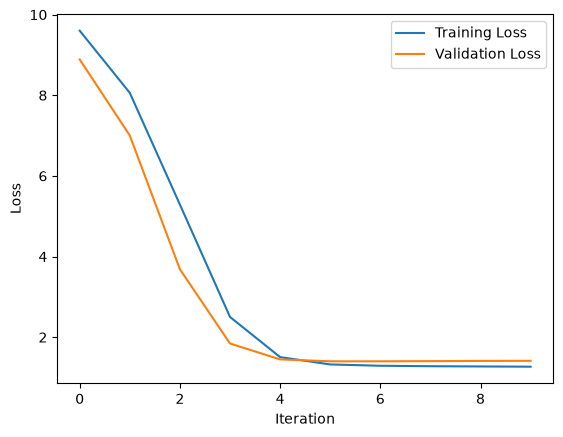

In [12]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()

# 12. Making Real Predictions

In [15]:
reco = recommend(model, 36, data, 5)
reco

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Item_ID,Predicted_rating
0,514,3.51
1,34,3.42
2,1964,3.39
3,26,3.29
4,335,3.26
